# Gráficos — Tempo (LED-36)

Consultas de [`analytics/01_consultas_tempo.sql`](01_consultas_tempo.sql), plotadas para
apoiar os slides de apresentação (LED-44). Conecta direto no `warehouse.duckdb` e consulta só
o modelo final (`fato_corrida` + dimensões).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

con = duckdb.connect('../warehouse.duckdb', read_only=True)

# Paleta categórica validada (ordem fixa, não ciclada) - ver skill de dataviz do projeto
BLUE = '#2a78d6'    # baseline / dia útil / fora de pico
ORANGE = '#eb6834'  # destaque / fim de semana / pico
TEXT = '#0b0b0b'
MUTED = '#52514e'
GRID = '#e5e4e0'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': MUTED,
    'axes.labelcolor': TEXT,
    'text.color': TEXT,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.size': 11,
})

def style_ax(ax, grid_axis='y'):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def milhar(x, _=None):
    return f'{int(x):,}'.replace(',', '.')

## Volume por dia da semana

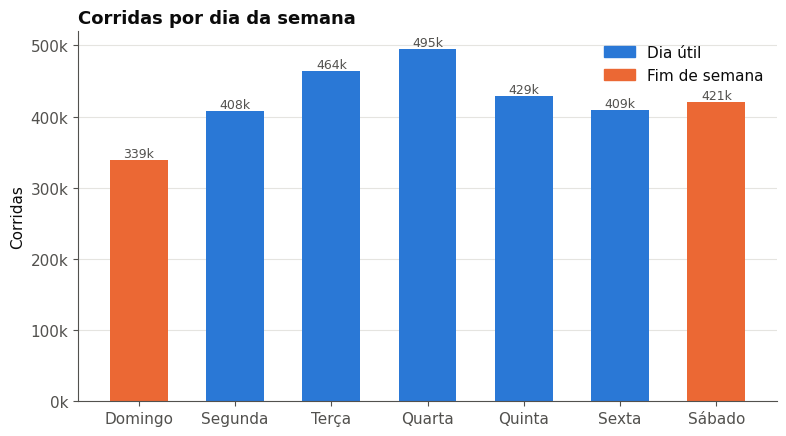

In [2]:
df = con.execute('''
    SELECT d.dia_semana_nome, d.dia_semana_num, d.fim_de_semana, COUNT(*) AS qtd_corridas
    FROM fato_corrida f
    JOIN dim_data d ON d.id_data_sk = f.id_data_embarque_sk
    GROUP BY d.dia_semana_nome, d.dia_semana_num, d.fim_de_semana
    ORDER BY d.dia_semana_num
''').fetchdf()

colors = [ORANGE if fs else BLUE for fs in df['fim_de_semana']]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(df['dia_semana_nome'], df['qtd_corridas'], color=colors, width=0.6)
ax.set_title('Corridas por dia da semana', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('Corridas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
style_ax(ax)
for b in bars:
    ax.annotate(f'{b.get_height()/1000:.0f}k', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9, color=MUTED)
ax.legend(handles=[Patch(color=BLUE, label='Dia útil'), Patch(color=ORANGE, label='Fim de semana')],
          frameon=False, loc='upper right')
plt.tight_layout()
plt.show()

Quarta é o dia de maior volume; fins de semana têm menos corridas, mas as mais longas em duração média (ver tabela de `01_consultas_tempo.sql`).

## Volume por hora do dia

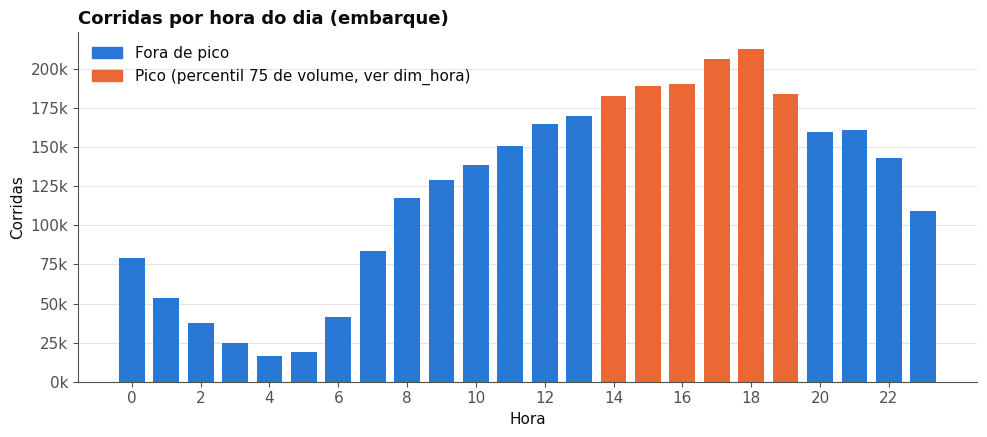

In [3]:
df = con.execute('''
    SELECT h.id_hora_sk AS hora, h.turno, h.faixa_pico, COUNT(*) AS qtd_corridas
    FROM fato_corrida f
    JOIN dim_hora h ON h.id_hora_sk = f.id_hora_embarque_sk
    GROUP BY h.id_hora_sk, h.turno, h.faixa_pico
    ORDER BY h.id_hora_sk
''').fetchdf()

colors = [ORANGE if p else BLUE for p in df['faixa_pico']]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(df['hora'], df['qtd_corridas'], color=colors, width=0.75)
ax.set_title('Corridas por hora do dia (embarque)', loc='left', fontsize=13, fontweight='bold')
ax.set_xlabel('Hora')
ax.set_ylabel('Corridas')
ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
style_ax(ax)
ax.legend(handles=[Patch(color=BLUE, label='Fora de pico'), Patch(color=ORANGE, label='Pico (percentil 75 de volume, ver dim_hora)')],
          frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

Pico real cai entre 14h e 19h — vespertino/começo da noite, não o rush-hour matinal clássico.

## Duração das corridas

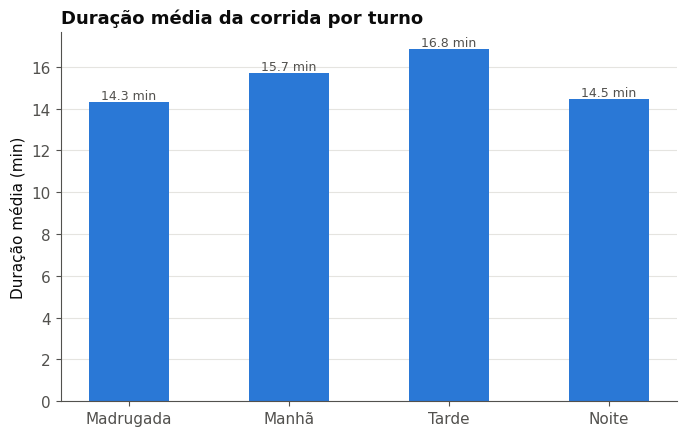

In [4]:
df = con.execute('''
    SELECT h.turno, COUNT(*) AS qtd_corridas, ROUND(AVG(f.trip_duration_minutes), 2) AS duracao_media_min
    FROM fato_corrida f JOIN dim_hora h ON h.id_hora_sk = f.id_hora_embarque_sk
    GROUP BY h.turno
''').fetchdf()
ordem = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
df['turno'] = pd.Categorical(df['turno'], categories=ordem, ordered=True)
df = df.sort_values('turno')

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(df['turno'], df['duracao_media_min'], color=BLUE, width=0.5)
ax.set_title('Duração média da corrida por turno', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('Duração média (min)')
style_ax(ax)
for b in bars:
    ax.annotate(f'{b.get_height():.1f} min', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

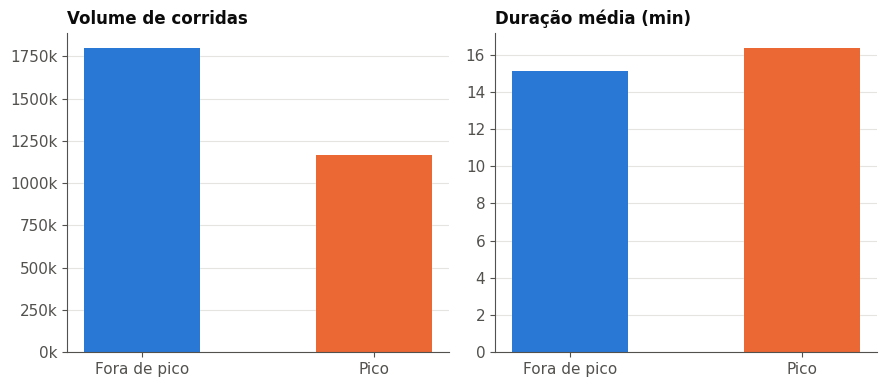

In [5]:
df = con.execute('''
    SELECT h.faixa_pico, COUNT(*) AS qtd_corridas, ROUND(AVG(f.trip_duration_minutes), 2) AS duracao_media_min
    FROM fato_corrida f JOIN dim_hora h ON h.id_hora_sk = f.id_hora_embarque_sk
    GROUP BY h.faixa_pico
    ORDER BY h.faixa_pico
''').fetchdf()
df['label'] = df['faixa_pico'].map({False: 'Fora de pico', True: 'Pico'})
cores = [BLUE, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(df['label'], df['qtd_corridas'], color=cores, width=0.5)
axes[0].set_title('Volume de corridas', loc='left', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
style_ax(axes[0])

axes[1].bar(df['label'], df['duracao_media_min'], color=cores, width=0.5)
axes[1].set_title('Duração média (min)', loc='left', fontsize=12, fontweight='bold')
style_ax(axes[1])

plt.tight_layout()
plt.show()

Pico concentra mais corridas e também dura mais em média — coerente com trânsito mais pesado no fim de tarde.

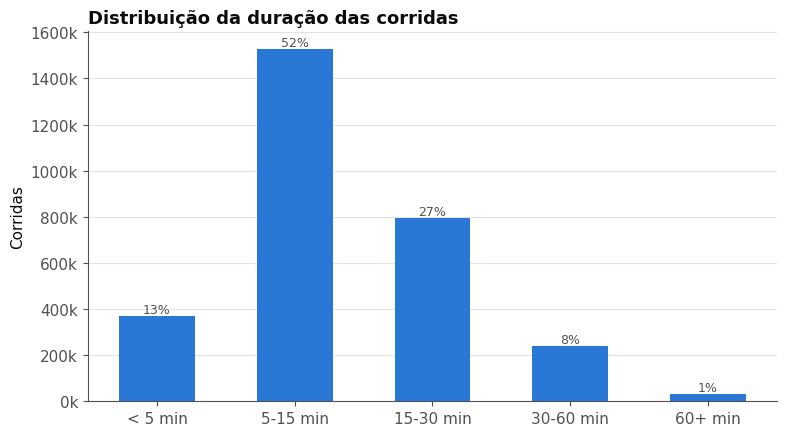

In [6]:
df = con.execute('''
    SELECT CASE
        WHEN trip_duration_minutes < 5  THEN '< 5 min'
        WHEN trip_duration_minutes < 15 THEN '5-15 min'
        WHEN trip_duration_minutes < 30 THEN '15-30 min'
        WHEN trip_duration_minutes < 60 THEN '30-60 min'
        ELSE '60+ min'
    END AS faixa_duracao,
    COUNT(*) AS qtd_corridas
    FROM fato_corrida
    GROUP BY faixa_duracao
''').fetchdf()
ordem = ['< 5 min', '5-15 min', '15-30 min', '30-60 min', '60+ min']
df['faixa_duracao'] = pd.Categorical(df['faixa_duracao'], categories=ordem, ordered=True)
df = df.sort_values('faixa_duracao')
total = df['qtd_corridas'].sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(df['faixa_duracao'], df['qtd_corridas'], color=BLUE, width=0.55)
ax.set_title('Distribuição da duração das corridas', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('Corridas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
style_ax(ax)
for b in bars:
    pct = b.get_height() / total * 100
    ax.annotate(f'{pct:.0f}%', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()